In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import os
import psutil # Pastikan sudah install: pip install psutil

# Import dasar untuk SklearnWrapper
from sklearn.base import BaseEstimator, RegressorMixin

# Import model-model yang digunakan dalam base_estimators
from sklearn.ensemble import (StackingRegressor, RandomForestRegressor, 
                              ExtraTreesRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR

# Import model pihak ketiga (pastikan sudah install: pip install xgboost lightgbm catboost)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [3]:
# 1. LOAD DATA
df = pd.read_excel('#1 final feature selected dataset 6 for nphr.xlsx')
X = df.drop(columns=['NPHR (Kcal/Kwh)'])
y = df['NPHR (Kcal/Kwh)']


In [4]:
df

,Gross Load (MW),Coal Flow (t/h),Dust (mg/nm3),Main steam temperature (turbine side) (℃),O2 (%),Circulating water outlet temperature (℃),CO (mg/nm3),Temperature HRH,Flue gas temperature (℃),Flow rate (KNm3/h),HHV (Kcal/Kg),Opacity (%),NPHR (Kcal/Kwh)
0,344.56,192.41,0.269452,564.647756,5.733319,36.582086,675.494230,566.36,130.708067,521.201534,4389.444444,49.690183,2607.270106
1,316.02,181.37,0.270812,564.466986,5.007743,36.544537,677.919792,565.00,129.803971,465.376223,4389.444444,49.691542,2687.121676
2,314.22,178.47,0.272701,565.077340,4.783563,36.551775,679.644721,565.63,127.860081,457.962513,4389.444444,49.697809,2663.032090
3,304.68,172.09,0.274674,564.828538,4.842330,36.504076,682.033313,564.09,129.812856,446.929254,4389.444444,49.702891,2651.943177
4,320.94,181.74,0.283205,564.945778,5.686940,36.704238,478.544209,565.75,130.218360,465.797638,4389.444444,49.688853,2651.524408
...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,329.71,172.99,7.591082,563.225716,6.027527,37.889208,791.996076,565.60,124.009406,498.582860,4237.333333,49.763117,2362.587163
545,307.55,164.77,7.572601,563.826204,6.173781,37.821999,792.244088,565.79,123.268547,472.191265,4237.333333,49.763391,2421.984297
546,303.77,169.38,7.570885,563.660633,6.020364,37.215704,792.396151,565.84,124.640201,465.546617,4237.333333,49.768304,2522.739965
547,314.09,179.69,7.570648,563.597101,5.799353,37.905170,791.685285,566.30,127.187321,483.710499,4237.333333,49.766662,2584.543200


In [5]:
# 2. SETUP EKSPERIMEN
sample_sizes = np.linspace(0.1, 1.0, 10) 
n_records = []
training_times = []
inference_times = []



In [6]:
# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags


# ==========================================
# 3. LOOPING UNTUK MENGUKUR WAKTU
# ==========================================
print(f"{'N':<8} | {'Train Time (s)':<15} | {'Inf Time (s)':<15}")
print("-" * 45)

# 3. LOOPING PENGUKURAN
for prop in sample_sizes:
    n = int(len(df) * prop)
    X_subset = X.iloc[:n]
    y_subset = y.iloc[:n]
    n_records.append(n)

    # ----------------------------------------------------
    # SETUP STACKING REGRESSOR
    # ----------------------------------------------------
    # 1. Definisikan Base Models (Sesuaikan dengan model di notebook Anda)
    # Contoh di bawah ini menggunakan Random Forest dan XGBoost
    base_estimators = [
   ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
    ]
    
    # 2. Definisikan Final Estimator (Meta-model)
    final_estimator = RidgeCV()
    
    # 3. Gabungkan ke dalam StackingRegressor
    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=5 # Menggunakan 5-fold cross validation saat melatih meta-model
    )
    # ----------------------------------------------------
    
    # --- PENGUKURAN TRAINING ---
    start_train = time.time()
    model.fit(X_subset, y_subset)
    end_train = time.time()
    training_times.append(end_train - start_train)

    # --- PENGUKURAN INFERENCE (DETEKSI) ---
    start_inf = time.time()
    model.predict(X_subset)
    end_inf = time.time()
    inference_times.append(end_inf - start_inf)

    print(f"{n:<8} | {training_times[-1]:<15.4f} | {inference_times[-1]:<15.4f}")

N        | Train Time (s)  | Inf Time (s)   
---------------------------------------------
54       | 4.1338          | 0.0292         
109      | 5.1082          | 0.0285         
164      | 5.3083          | 0.0348         
219      | 7.3061          | 0.0372         
274      | 7.4632          | 0.0423         
329      | 8.3369          | 0.0467         
384      | 8.7014          | 0.0538         
439      | 9.5921          | 0.0555         
494      | 10.8483         | 0.0619         
549      | 11.0461         | 0.0693         


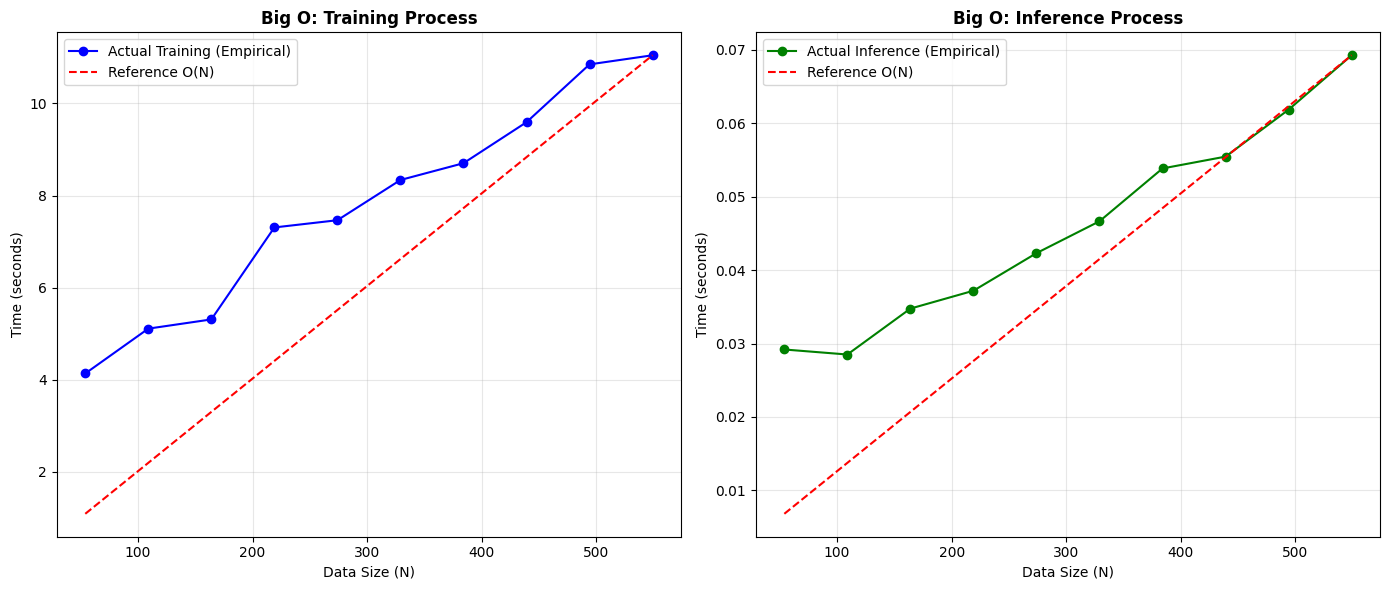

In [7]:
# 4. VISUALISASI PERBANDINGAN BIG O
plt.figure(figsize=(14, 6))

# Subplot 1: Training
plt.subplot(1, 2, 1)
plt.plot(n_records, training_times, 'bo-', label='Actual Training (Empirical)')
train_linear = [training_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, train_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Training Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Inference
plt.subplot(1, 2, 2)
plt.plot(n_records, inference_times, 'go-', label='Actual Inference (Empirical)')
inf_linear = [inference_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, inf_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Inference Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()